In [4]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
file_path = '/content/drive/MyDrive/auto judge/AutoJudge_cleaned_dataset.csv'
df = pd.read_csv(file_path)
df.head()

,title,description,input_description,output_description,clean_text,problem_class,problem_score
0,Uuu,Unununium (Uuu) was the name of the chemical\n...,The input consists of one line with two intege...,The output consists of $M$ lines where the $i$...,uuu unununium uuu was the name of the chemical...,hard,9.7
1,House Building,A number of eccentrics from central New York h...,"The input consists of $10$ test cases, which a...",Print $K$ lines with\n the positions of the...,house building a number of eccentrics from cen...,hard,9.7
2,Mario or Luigi,Mario and Luigi are playing a game where they ...,NaN,NaN,mario or luigi mario and luigi are playing a g...,hard,9.6
3,The Wire Ghost,Žofka is bending a copper wire. She starts wit...,The first line contains two integers $L$ and $...,The output consists of a single line consistin...,the wire ghost ofka is bending a copper wire s...,hard,9.6
4,Barking Up The Wrong Tree,"Your dog Spot is let loose in the park. Well, ...",The first line of input consists of two intege...,Write a single line containing the length need...,barking up the wrong tree your dog spot is let...,hard,9.6


In [8]:
X_text = df['clean_text']

y_class = df['problem_class']    # Classification target
y_score = df['problem_score']

### Feature Extraction


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 3),
    min_df=3,
    max_df=0.85,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(X_text)

In [10]:
print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (4112, 15000)


In [12]:
import joblib

joblib.dump(tfidf, r"C:\Users\User\Downloads\AutoJudge\tfidf_vectorizer.pkl")

['C:\\Users\\User\\Downloads\\AutoJudge\\tfidf_vectorizer.pkl']

In [ ]:
#adding text length feature
df['text_length'] = df['clean_text'].apply(len)

In [ ]:
import re

df['math_symbol_count'] = df['clean_text'].apply(
    lambda x: len(re.findall(r'[+\-*/=<>]', x))
)


In [ ]:
keywords = [
    'dp', 'dynamic programming', 'graph', 'tree',
    'dfs', 'bfs', 'shortest path',
    'segment tree', 'fenwick',
    'greedy', 'binary search',
    'recursion', 'backtracking'
]
def keyword_count(text):
    return sum(text.count(k) for k in keywords)

df['keyword_count'] = df['clean_text'].apply(keyword_count)

In [ ]:
from scipy.sparse import hstack

extra_features = df[['text_length', 'math_symbol_count','keyword_count']].values
X_final = hstack([X_tfidf, extra_features])

In [ ]:
print("Final feature shape:", X_final.shape)

Final feature shape: (4112, 15003)


## Model Trainig

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight='balanced'
    ),
    "SVM (Linear)": LinearSVC(
        class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, random_state=42
    )
}


In [ ]:
from sklearn.metrics import confusion_matrix
def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


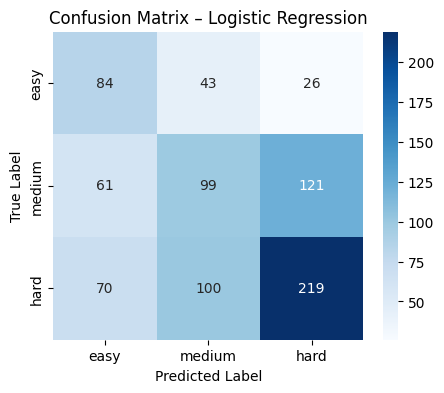

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


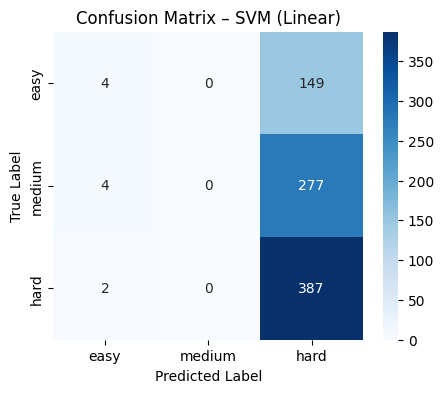

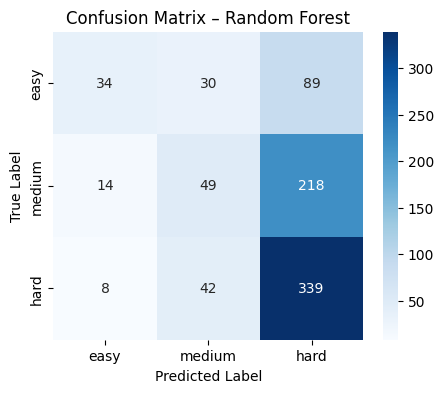

In [ ]:
from sklearn.metrics import accuracy_score

results = {}
labels = ['easy', 'medium', 'hard']

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    plot_confusion_matrix(
        y_test,
        y_pred,
        labels=labels,
        title=f"Confusion Matrix – {name}"
    )


In [ ]:
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")


Logistic Regression: 0.4885
SVM (Linear): 0.4751
Random Forest: 0.5128


In [ ]:
import pandas as pd

accuracy_df = pd.DataFrame(
    results.items(),
    columns=["Model", "Accuracy"]
)

accuracy_df


,Model,Accuracy
0,Logistic Regression,0.488457
1,SVM (Linear),0.475091
2,Random Forest,0.512758


In [ ]:
joblib.dump(models["Random Forest"], "/content/drive/MyDrive/auto judge/difficulty_score_classifie.pkl")

['/content/drive/MyDrive/auto judge/difficulty_score_classifie.pkl']

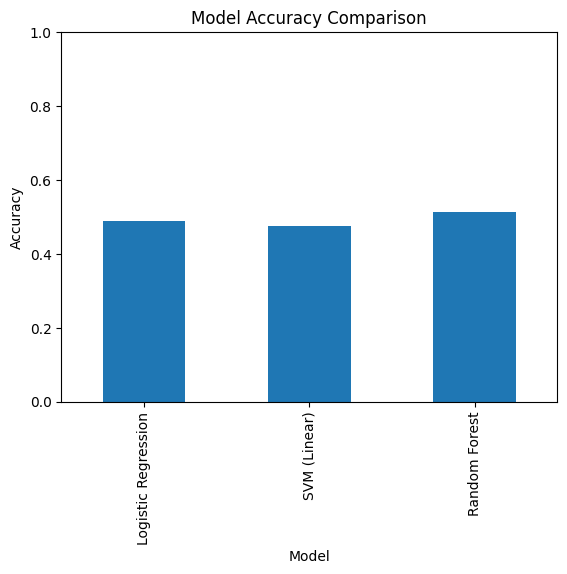

In [ ]:
import matplotlib.pyplot as plt

accuracy_df.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()


## regression model

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y_score,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
reg_models = {
    "Linear Regression": LinearRegression(),

    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
import numpy as np

reg_results = []

for name, model in reg_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    reg_results.append([name, mae, rmse, r2])


In [ ]:
reg_results_df = pd.DataFrame(
    reg_results,
    columns=["Model", "MAE", "RMSE", "r2_score"]
)

reg_results_df


,Model,MAE,RMSE,r2_score
0,Linear Regression,1.864088,2.294124,-0.096404
1,Random Forest Regressor,1.672177,2.024218,0.146406
2,Gradient Boosting Regressor,1.710312,2.049521,0.124933


In [ ]:
import joblib

best_regressor = reg_models["Gradient Boosting Regressor"]
joblib.dump(best_regressor, "/content/drive/MyDrive/auto judge/difficulty_score_regressor.pkl")


['/content/drive/MyDrive/auto judge/difficulty_score_regressor.pkl']